In [1]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

from util import *

In [2]:
def _planck(t, eps=1.0):
    sigma = 5.67e-8
    return eps * sigma * t**4

In [3]:
models = list_models()
models

['proteus', 'gooey', 'lincs', 'moai', 'neongooey', 'pacman']

In [4]:
models_data = {}
for m in models:
    models_data[m] = load_model_data(m)

Loading model proteus
    earth
        Hhigh-Chigh
        Hhigh-Cmid
        Hhigh-Clow
        Hmid-Chigh
        Hmid-Cmid
        Hmid-Clow
        Hlow-Chigh
        Hlow-Cmid
        Hlow-Clow
    venus
        nominal
        Hhigh-Chigh
        Hhigh-Cmid
        Hhigh-Clow
        Hmid-Chigh
        Hmid-Cmid
        Hmid-Clow
        Hlow-Chigh
        Hlow-Cmid
        Hlow-Clow
Loading model gooey
    earth
        nominal
        Hhigh-Chigh
        Hhigh-Cmid
        Hhigh-Clow
        Hmid-Chigh
        Hmid-Cmid
        Hmid-Clow
        Hlow-Chigh
        Hlow-Cmid
        Hlow-Clow
    venus
        nominal
        Hhigh-Chigh
        Hhigh-Cmid
        Hhigh-Clow
        Hmid-Chigh
        Hmid-Cmid
        Hmid-Clow
        Hlow-Chigh
        Hlow-Cmid
        Hlow-Clow
Loading model lincs
    earth
        nominal
        Hhigh-Chigh
        Hhigh-Cmid
        Hhigh-Clow
        Hmid-Chigh
        Hmid-Cmid
        Hmid-Clow
        Hlow-Chigh
        Hlow-Cmid
  

In [5]:
planets = list_planets()
planets

('earth', 'venus')

In [6]:
print(", ".join(models_data["proteus"]["earth"]["Hhigh-Chigh-evo"].keys()))

t(yr), T_surf(K), T_pot(K), flux_surf(W/m2), flux_OLR(W/m2), flux_ASR(W/m2), phi(vol_frac), fO2_melt(bar), fO2_solid(bar), thick_surf_bl(m), massC_solid(kg), massC_melt(kg), massC_atm(kg), massH_solid(kg), massH_melt(kg), massH_atm(kg), massO_atm(kg), p_surf(bar), p_H2O(bar), p_CO2(bar), p_CO(bar), p_H2(bar), p_CH4(bar), p_O2(bar), mmw(kg/mol), R_trans(m), R_solid(m), viscosity(Pa.s), phi(mass_frac), p_SO2(bar), p_NH3(bar), p_N2(bar), p_H2S(bar), p_S2(bar)


## Tsurf vs Phi

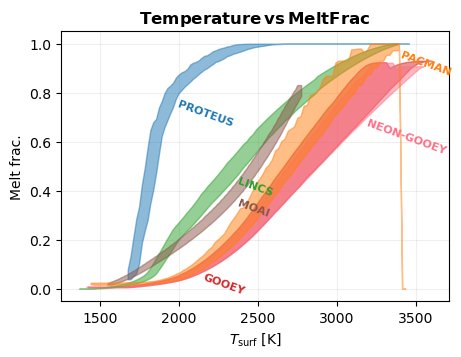

In [7]:
fig,ax = plt.subplots(1,1, figsize=(5,3.5))


xkey = "T_surf(K)"
ykey = "phi(vol_frac)"

for im,m in enumerate(models):
    c = get_color(m)

    x = []
    y = []
    for p in planets:
        for case,v in models_data[m][p].items():
            if "-evo" not in case:
                continue
            x.extend(v["T_surf(K)"].values)
            y.extend(v["phi(vol_frac)"].values)

    # sort data
    mask = np.argsort(x)
    x = np.array(x)[mask]
    y = np.array(y)[mask]
    # ax.scatter(x, y, color=c, ec='none', s=3, alpha=0.2, zorder=8)

    # convert to filled region
    xx = np.linspace(min(x), max(x), 100)
    dx = 25
    ytop, ybot = [], []
    for i in range(len(xx)):
        mask = np.argwhere(abs(x-xx[i])<=dx).flatten()
        ytop.append(np.amax(y[mask]))
        ybot.append(np.amin(y[mask]))

    ax.fill_between(xx, ybot, ytop, color=c, alpha=0.5, zorder=10)

    l = get_label(m)
    i = np.argmin(np.abs(ybot-np.percentile(ybot,(1+im)*100/len(models))))
    ax.text(xx[i], ybot[i], l, color=c, fontsize=8, ha='left', va='top', rotation=-20, zorder=30, weight='bold')

ax.grid(alpha=0.2, zorder=0)
ax.set_xlabel(get_label(xkey))
ax.set_ylabel(get_label(ykey))

title = r"$\bf Temperature\,vs\,MeltFrac$"
ax.set_title(title)

plt.show()

## Temperature over time

In [8]:
t_ini = 50e6 # years

ages_Ga = {
    "CAI":              4.57,
    "Earth formed":     4.54,
    "Moon formed":      4.34,
    "MO early":         4.33,
    "MO late" :         4.20,
    "GOE early":        2.5,
    "GOE late" :        2.2,
}

ages_yr = {k: (ages_Ga["CAI"] - v ) * 1e9 - t_ini for k, v in ages_Ga.items()}

proteus
gooey
lincs
moai
neongooey
pacman


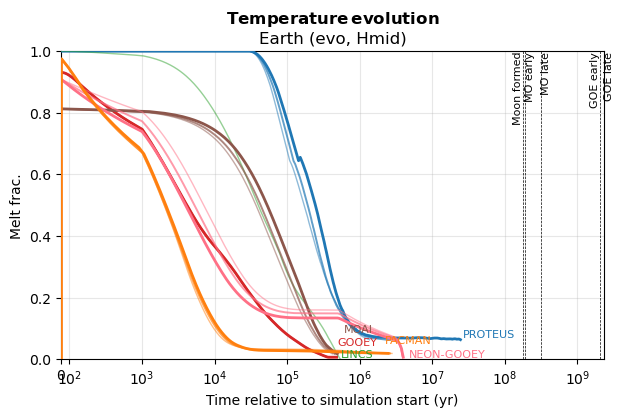

In [9]:
fig,ax = plt.subplots(1,1, figsize=(7,4))

xkey = "t(yr)"
ykey = "phi(vol_frac)"
planet = "earth"

controls = ["evo", "Hmid"]

txts = []

ymax = 1
ymin = 0
for m in models:
    print(m)
    d = models_data[m][planet]
    col = get_color(m)
    lbl = get_label(m)

    for case in d.keys():
        if np.all([c in case for c in controls]):

            if "Chigh" in case:
                sf = 1.0
            elif "Cmid" in case:
                sf = 0.7
            else:
                sf = 0.5


            x = d[case][xkey] 
            y = d[case][ykey]
            ax.plot(x, y, label=lbl, color=col, lw=sf*2, alpha=sf*1, zorder=4)

            if lbl != "":
                l = ax.text(x.iloc[-1], y.iloc[-1], lbl, color=col, fontsize=8, zorder=5)
                txts.append(l)

            lbl = ""
            # ymax = max(ymax, np.max(y))
            ymin = min(ymin, np.min(y))


# add vertical lines for ages of interest
for k, x in ages_yr.items():
    ax.axvline(x, color="k", ls="--", lw=0.5, zorder=6)
    va = 'top'
    if k in ["Moon formed", "GOE early"]:
        va = 'bottom'
    ax.annotate(k, xy=(x, ymax), ha="right", va=va, fontsize=8, rotation=90, rotation_mode='anchor')

ax.axvline(x=0, color="k", ls="-", lw=0.5)

ax.set_xscale("symlog", linthresh=1e3)
ax.set_xlabel("Time relative to simulation start (yr)")
ax.set_xlim(left=0, right=ages_yr["GOE late"])

ax.set_ylabel(get_label(ykey))
ax.set_ylim(ymin, ymax)

ax.grid(alpha=0.3, zorder=-2)

# legend of models
# ax.legend(loc='upper left', bbox_to_anchor=(0, -0.2), ncols=4, frameon=False, handletextpad=0.5)

title = r"$\bf Temperature\,evolution$" + "\n" + get_label(planet) + f" ({', '.join(controls)})"
ax.set_title(title)

adjust_text(txts)


plt.show()

proteus
gooey
lincs
moai
neongooey
pacman


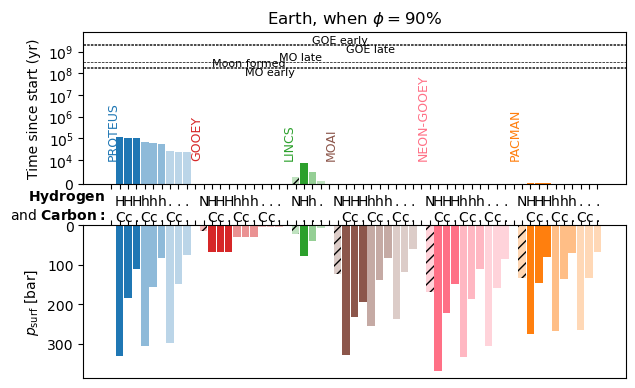

proteus
gooey
lincs
moai
neongooey
pacman


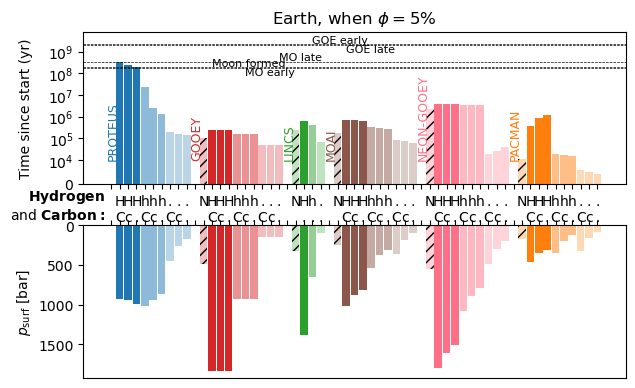

In [10]:
def plot_bars(phi_compare):

    fig, axs = plt.subplots(2,1, figsize=(7,4.5))

    axt, axb = axs

    ykey_t = "t(yr)"
    ykey_b = "p_surf(bar)"

    xlbl  = []
    xlocs = []
    for m in models:
        print(m)
        d = models_data[m]["earth"]
        col = get_color(m)
        lbl = get_label(m)

        # spacer
        axt.bar(m,0)
        axb.bar(m,0)
        xlocs.append(m)
        xlbl.append("")
        
        xlbl_this = None
        for case in d.keys():
            if "evo" in case:

                if "Hhigh" in case:
                    sf = 1.0
                elif "Hmid" in case:
                    sf = 0.5
                else:
                    sf = 0.3

                idx = np.argmin(np.abs(d[case]["phi(vol_frac)"] - phi_compare))

                yt = d[case][ykey_t].iloc[idx]
                yb = d[case][ykey_b].iloc[idx]
                x = m + case
                c = get_color(m)
                a = sf

                if xlbl_this is None:
                    xlbl_this = x

                hatch = ''
                if "nominal" in case:
                    hatch = '///'

                axt.bar(x, yt, color=c, alpha=a, width=0.9, hatch=hatch)
                axb.bar(x, yb, color=c, alpha=a, width=0.9, hatch=hatch)
                xlocs.append(x)

                x = case
                for xo,xn in (("-evo","", ), ("nominal","N"), ("Hhigh", "H"), ("Hmid", "h"), ("Hlow", "."), ("Chigh","C"), ("Cmid","c"), ("Clow","."), ("-","\n")):
                    x = x.replace(xo, xn)
                xlbl.append(x)

        axt.text(xlbl_this, 1e4, lbl, ha="left", va="bottom", fontsize=9, color=col, rotation=90, rotation_mode="anchor")
        
    i = 0
    for k, x in ages_yr.items():
        i += 1
        axt.axhline(x, color="k", ls="--", lw=0.5, zorder=6)
        va = 'top'
        if k in ["Moon formed", "GOE early", "MO late"]:
            va = 'bottom'
        axt.annotate(k, xy=(xlocs[i*4], x), ha="left", va=va, fontsize=8)


    anno = r"$\bf{Hydrogen}$" + "\nand " + r"$\bf{Carbon:}$"
    axt.text(0.04,-0.02, anno, va='top', ha='right', transform=axt.transAxes)

    axt.set_ylabel("Time since start (yr)")
    axt.set_yscale("symlog", linthresh=1e4)
    axt.set_ylim(bottom=0)

    axb.set_ylabel(get_label(ykey_b))
    axb.invert_yaxis()
    # axb.set_yscale("log")

    # show ticks on top panel and hide bottom
    axt.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
    axt.set_xticks(xlocs,xlbl, fontsize=10)
    axb.tick_params(axis='x', which='both', bottom=False, top=True,)
    axb.set_xticks(xlocs,[])

    fig.align_ylabels()
    axt.set_title(get_label(planet) +  r", when $\phi=$" + f"{phi_compare*100:.0f}%")

    fig.subplots_adjust(hspace=0.27)

    adjust_text(txts)

    plt.show()

plot_bars(phi_compare=0.9)
plot_bars(phi_compare=0.05)

## Cooling rate as a function of temperature

proteus
gooey
lincs
moai
neongooey
pacman


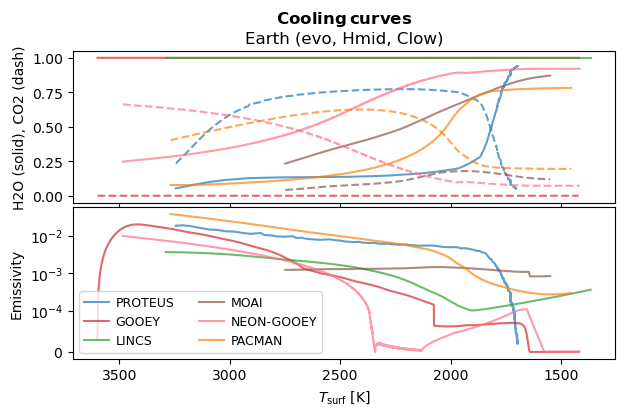

In [11]:
fig,axs = plt.subplots(2,1, figsize=(7,4), sharex=True)
axt, axb = axs

controls = ["evo", "Hmid", "Clow"]
xkey = "T_surf(K)"

for m in models:
    print(m)
    d = models_data[m]["earth"]
    col = get_color(m)
    lbl = get_label(m)

    for case in d.keys():
        if np.all([param in case for param in controls]):

            # idx = np.argmin(np.abs(d[case]["phi(vol_frac)"] - phi_compare))
            row = d[case]#.iloc[idx]

            col = get_color(m)
            al = 0.7

            mask = np.argsort(row[xkey])[::-1][10:]
            row = row.iloc[mask]
            
            x = np.array(row[xkey])

            y = np.array(row[f"p_H2O(bar)"]/row["p_surf(bar)"])
            axt.plot(x, y, color=col, alpha=al, ls='-')

            y = np.array(row[f"p_CO2(bar)"]/row["p_surf(bar)"])
            axt.plot(x, y, color=col, alpha=al, ls='--')

            y = np.array(row["flux_surf(W/m2)"]/_planck(row["T_surf(K)"]))
            axb.plot(x, y, color=col, alpha=al, label=lbl, zorder=4)


axt.set_ylabel("H2O (solid), CO2 (dash)")
# axt.set_yscale("symlog", linthresh=1e-3)

axb.set_xlabel(get_label(xkey))
axb.set_ylabel("Emissivity")
axb.set_yscale("symlog", linthresh=1e-4)

axb.invert_xaxis()
axb.legend(loc='lower left', bbox_to_anchor=(0, 0), ncols=2, fontsize=9, handletextpad=0.5)

title = r"$\bf Cooling\,curves$" + "\n" + get_label(planet) + f" ({', '.join(controls)})"
axt.set_title(title)

fig.subplots_adjust(hspace=0.03)

plt.show()


## Earth versus Venus

proteus
gooey
lincs
moai
neongooey
pacman


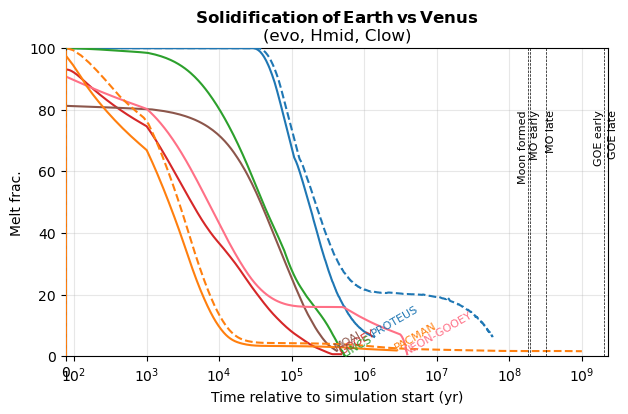

In [12]:
fig, ax = plt.subplots(1,1, figsize=(7,4))

xkey = "t(yr)"
ykey = "phi(vol_frac)"
controls = ["evo", "Hmid", "Clow"]

for m in models:
    print(m)

    if any([len(models_data[m][p]) == 0 for p in planets]):
        print("skipping model", m, "because of missing data")
        continue

    for p in planets:

        d = models_data[m][p]
        col = get_color(m)

        if p == "earth":
            ls = "-"
            lbl = get_label(m)
        else:
            ls = "--"
            lbl = ""


        for case in d.keys():
            if np.all([param in case for param in controls]):

                x = d[case][xkey] 
                y = d[case][ykey] * 100
                ax.plot(x, y, color=col, ls=ls, zorder=4)
                if lbl != "":
                    ax.annotate(lbl, (x.iloc[-1], y.iloc[-1]), color=col, fontsize=8, zorder=5, rotation=30, rotation_mode='anchor', ha='left')


# add vertical lines for ages of interest
for k, x in ages_yr.items():
    ax.axvline(x, color="k", ls="--", lw=0.5, zorder=6)
    va = 'top'
    if k in ["Moon formed", "GOE early"]:
        va = 'bottom'
    ax.annotate(k, xy=(x, 80), ha="right", va=va, fontsize=8, rotation=90, rotation_mode='anchor')

ax.axvline(x=0, color="k", ls="-", lw=0.5)

ax.set_xscale("symlog", linthresh=1e3)
ax.set_xlabel("Time relative to simulation start (yr)")
ax.set_xlim(left=0, right=ages_yr["GOE late"])

ax.set_ylabel(get_label(ykey))
ax.set_ylim(0, 100)

ax.set_title(get_label(planet) + f" ({", ".join(controls)})")
ax.grid(alpha=0.3, zorder=-2)

title = r"$\bf Solidification\,of\,Earth\,vs\,Venus$" + "\n" + f"({', '.join(controls)})"
ax.set_title(title)

plt.show()

## Chemistry

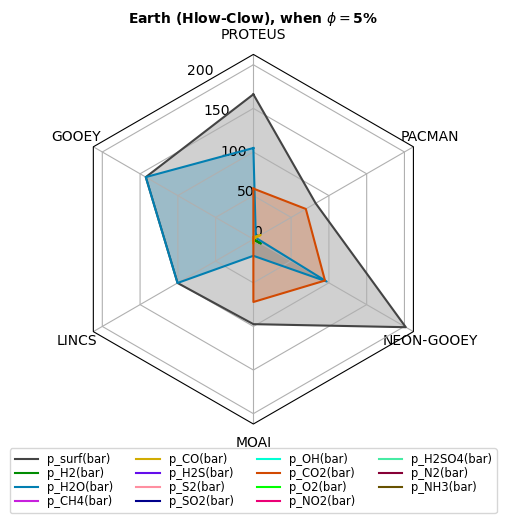

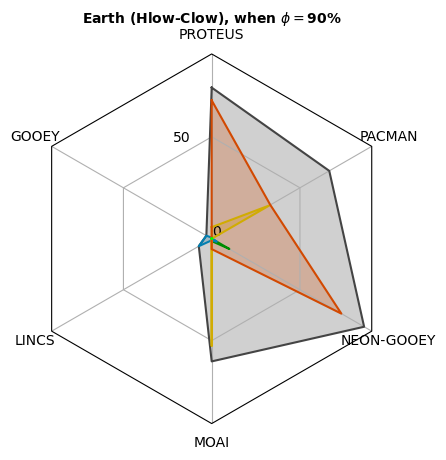

In [13]:


def radar_factory(num_vars, frame='circle'):
    """
    Create a radar chart with `num_vars` Axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle', 'polygon'}
        Shape of frame surrounding Axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):

        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta


radar_vars = ["p_surf(bar)"]
radar_vars.extend([f"p_{gas}(bar)" for gas in gas_list])
N = len(models)

def plot_radar(case, phi_compare, legend=True):

    theta = radar_factory(N, frame='polygon')


    fig, ax = plt.subplots(1,1,subplot_kw=dict(projection='radar'))
    # fig.subplots_adjust(wspace=0.25, hspace=0.20, top=0.85, bottom=0.05)

    
    title = get_label(planet) + f" ({case})" + r", when $\phi=$" + f"{phi_compare*100:.0f}%"
    ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.1),
                    horizontalalignment='center', verticalalignment='center')
    
    case_data = []
    for m in models:
        dat = models_data[m]["earth"][case+"-evo"]
        vals = []

        idx = np.argmin(np.abs(dat["phi(vol_frac)"] - phi_compare))

        for var in radar_vars:
            try:
                val = dat[var].iloc[idx]
            except KeyError:
                val = 0
            if np.isfinite(val):
                vals.append(val)
            else:
                vals.append(0)
        case_data.append(vals)
    case_data = np.array(case_data).T
    
    dt = 50
    if np.amax(case_data) > 500:
        dt = 100
    ticks = np.arange(0,np.amax(case_data),dt)
    ax.set_rgrids(ticks)

    for k,d in zip(radar_vars,case_data):
        ax.plot(theta, d, color=get_color(k))
        ax.fill(theta, d, facecolor=get_color(k), alpha=0.25, label='_nolegend_')
    ax.set_varlabels([get_label(model) for model in models])

    # add legend relative to top-left plot
    if legend:
        ax.legend(radar_vars, bbox_to_anchor=(0.5, -0.05), loc='upper center',  ncols=4,
                    labelspacing=0.1, fontsize='small', )

    plt.show()

plot_radar("Hlow-Clow", 0.05, legend=True)
plot_radar("Hlow-Clow", 0.90, legend=False)